In [1]:
import numpy as np
from scipy.stats import beta

alpha = [1, 1]  # successes
beta_values = [1, 1]  # failures

for i in range(100):
    # Sample from each arm
    samples = [
        beta.rvs(alpha[0], beta_values[0]),
        beta.rvs(alpha[1], beta_values[1])
    ]

    # Select arm with highest sample
    arm = np.argmax(samples)

    # Simulate reward
    success_rate = [0.6, 0.4]

    if np.random.rand() < success_rate[arm]:
        alpha[arm] += 1
    else:
        beta_values[arm] += 1

print("Red:", alpha[0], beta_values[0])
print("Blue:", alpha[1], beta_values[1])

Red: 54 41
Blue: 3 6


FINAL THOMPSON SAMPLING RESULTS

Variant A
Selections       : 914
Conversions      : 52
Observed Rate    : 0.0569
Alpha            : 53
Beta             : 863
Posterior Mean   : 0.0579

Variant B
Selections       : 7138
Conversions      : 468
Observed Rate    : 0.0656
Alpha            : 469
Beta             : 6671
Posterior Mean   : 0.0657

Variant C
Selections       : 1948
Conversions      : 112
Observed Rate    : 0.0575
Alpha            : 113
Beta             : 1837
Posterior Mean   : 0.0579


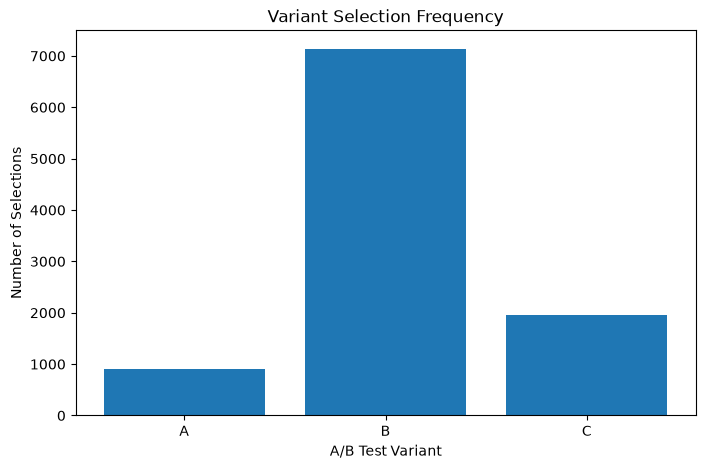

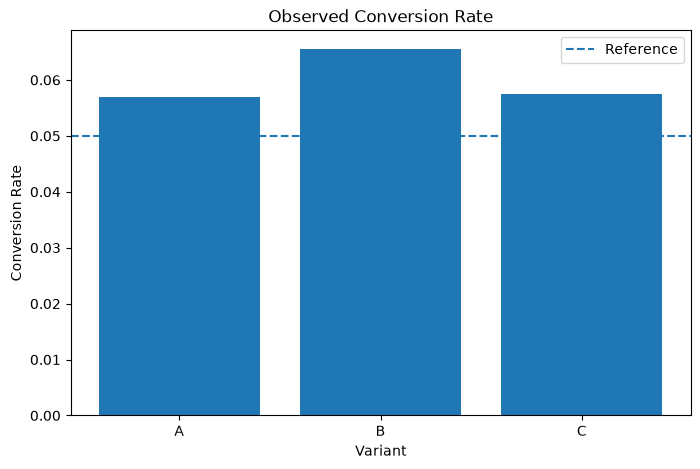

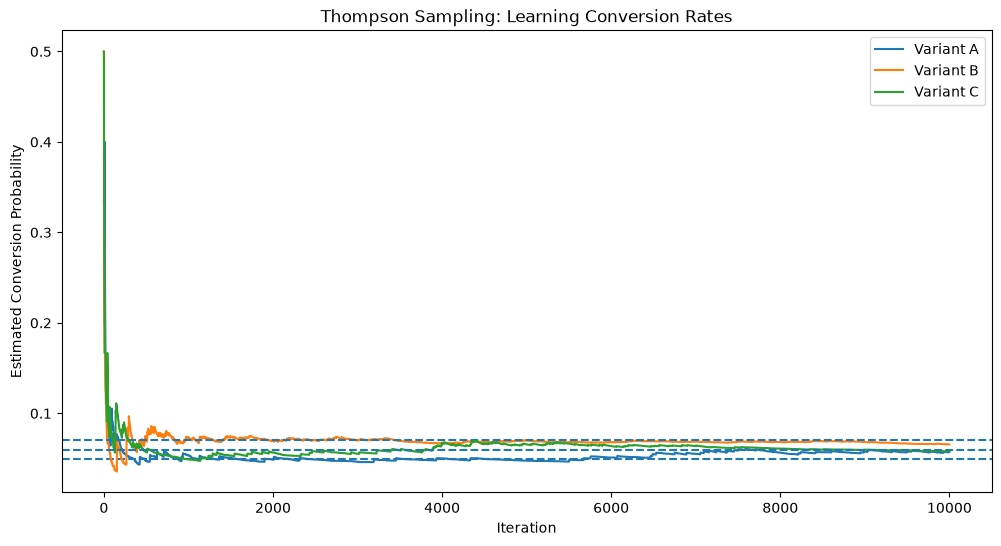

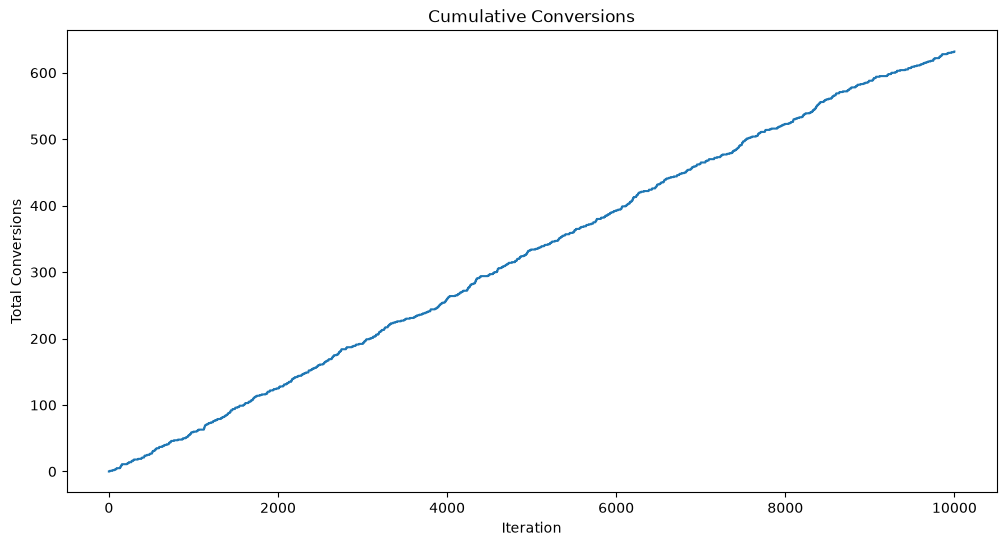

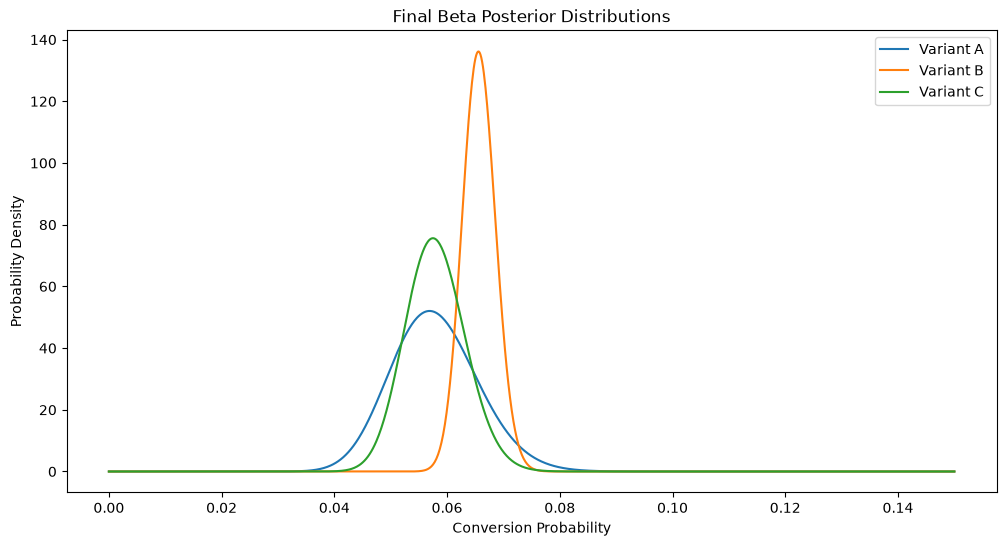

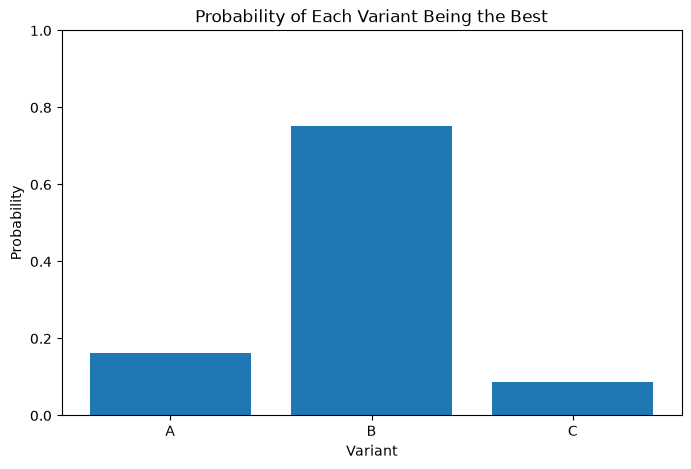


Variant with highest posterior probability of being best: B


In [3]:
# ============================================================
# THOMPSON SAMPLING FOR A/B TESTING
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# ------------------------------------------------------------
# 1. Experiment Configuration
# ------------------------------------------------------------

np.random.seed(42)

n_iterations = 10000

# True conversion rates (unknown to the algorithm)
true_conversion_rates = {
    "A": 0.05,
    "B": 0.07,
    "C": 0.06
}

variants = list(true_conversion_rates.keys())

# ------------------------------------------------------------
# 2. Initialize Beta distributions
# ------------------------------------------------------------

alpha = {variant: 1 for variant in variants}
beta_param = {variant: 1 for variant in variants}

# Tracking
selections = {variant: 0 for variant in variants}
conversions = {variant: 0 for variant in variants}

history_selected = []
history_reward = []

cumulative_rewards = []

posterior_history = {
    variant: []
    for variant in variants
}

# ------------------------------------------------------------
# 3. Thompson Sampling
# ------------------------------------------------------------

total_reward = 0

for iteration in range(n_iterations):

    # Sample conversion probability from each posterior
    samples = {
        variant: np.random.beta(
            alpha[variant],
            beta_param[variant]
        )
        for variant in variants
    }

    # Select variant with highest sampled probability
    selected_variant = max(
        samples,
        key=samples.get
    )

    # Simulate user conversion
    conversion = np.random.random() < true_conversion_rates[selected_variant]

    # Update statistics
    selections[selected_variant] += 1

    if conversion:
        conversions[selected_variant] += 1
        alpha[selected_variant] += 1
        reward = 1
    else:
        beta_param[selected_variant] += 1
        reward = 0

    # Track history
    history_selected.append(selected_variant)
    history_reward.append(reward)

    total_reward += reward
    cumulative_rewards.append(total_reward)

    # Store posterior means
    for variant in variants:

        posterior_mean = (
            alpha[variant]
            /
            (alpha[variant] + beta_param[variant])
        )

        posterior_history[variant].append(
            posterior_mean
        )


# ============================================================
# 4. Final Results
# ============================================================

print("=" * 60)
print("FINAL THOMPSON SAMPLING RESULTS")
print("=" * 60)

for variant in variants:

    conversion_rate = (
        conversions[variant] /
        selections[variant]
        if selections[variant] > 0
        else 0
    )

    posterior_mean = (
        alpha[variant]
        /
        (alpha[variant] + beta_param[variant])
    )

    print(f"\nVariant {variant}")
    print(f"Selections       : {selections[variant]}")
    print(f"Conversions      : {conversions[variant]}")
    print(f"Observed Rate    : {conversion_rate:.4f}")
    print(f"Alpha            : {alpha[variant]}")
    print(f"Beta             : {beta_param[variant]}")
    print(f"Posterior Mean   : {posterior_mean:.4f}")


# ============================================================
# 5. Selection Frequency
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    selections.keys(),
    selections.values()
)

plt.title("Variant Selection Frequency")
plt.xlabel("A/B Test Variant")
plt.ylabel("Number of Selections")

plt.show()


# ============================================================
# 6. Conversion Rate Comparison
# ============================================================

observed_rates = []

for variant in variants:

    rate = (
        conversions[variant] /
        selections[variant]
    )

    observed_rates.append(rate)


plt.figure(figsize=(8, 5))

plt.bar(
    variants,
    observed_rates
)

plt.axhline(
    true_conversion_rates["A"],
    linestyle="--",
    label="Reference"
)

plt.title("Observed Conversion Rate")
plt.xlabel("Variant")
plt.ylabel("Conversion Rate")

plt.legend()

plt.show()


# ============================================================
# 7. Posterior Mean Over Time
# ============================================================

plt.figure(figsize=(12, 6))

for variant in variants:

    plt.plot(
        posterior_history[variant],
        label=f"Variant {variant}"
    )

    # True conversion rate
    plt.axhline(
        true_conversion_rates[variant],
        linestyle="--"
    )

plt.title(
    "Thompson Sampling: Learning Conversion Rates"
)

plt.xlabel("Iteration")
plt.ylabel("Estimated Conversion Probability")

plt.legend()

plt.show()


# ============================================================
# 8. Cumulative Reward
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    cumulative_rewards
)

plt.title("Cumulative Conversions")
plt.xlabel("Iteration")
plt.ylabel("Total Conversions")

plt.show()


# ============================================================
# 9. Posterior Beta Distributions
# ============================================================

x = np.linspace(0, 0.15, 1000)

plt.figure(figsize=(12, 6))

for variant in variants:

    y = beta.pdf(
        x,
        alpha[variant],
        beta_param[variant]
    )

    plt.plot(
        x,
        y,
        label=f"Variant {variant}"
    )

plt.title(
    "Final Beta Posterior Distributions"
)

plt.xlabel("Conversion Probability")
plt.ylabel("Probability Density")

plt.legend()

plt.show()


# ============================================================
# 10. Probability of Being the Best Variant
# ============================================================

n_simulations = 100000

samples = np.zeros(
    (n_simulations, len(variants))
)

for i, variant in enumerate(variants):

    samples[:, i] = np.random.beta(
        alpha[variant],
        beta_param[variant],
        n_simulations
    )

best_variant_indices = np.argmax(
    samples,
    axis=1
)

probability_best = {}

for i, variant in enumerate(variants):

    probability_best[variant] = np.mean(
        best_variant_indices == i
    )


plt.figure(figsize=(8, 5))

plt.bar(
    probability_best.keys(),
    probability_best.values()
)

plt.title(
    "Probability of Each Variant Being the Best"
)

plt.xlabel("Variant")
plt.ylabel("Probability")

plt.ylim(0, 1)

plt.show()


# ============================================================
# 11. Final Recommendation Based on Posterior
# ============================================================

best_variant = max(
    probability_best,
    key=probability_best.get
)

print("\n" + "=" * 60)
print(f"Variant with highest posterior probability of being best: {best_variant}")
print("=" * 60)